In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File WindFarmA/0: train=16,032 | test=2,494 | class1=4,032
File WindFarmA/3: train=20,825 | test=3,302 | class1=8,825
File WindFarmA/10: train=17,859 | test=1,268 | class1=5,859
File WindFarmA/13: train=20,175 | test=3,583 | class1=8,175
File WindFarmA/14: train=14,010 | test=1,901 | class1=2,010


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       7.52 GB / 12.67 GB (59.4%)
Disk Space Avail:   75.04 GB / 107.72 GB (69.7%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` v

File WindFarmA/17: train=17,985 | test=2,781 | class1=5,985

Combined → Train: 106,886 | Test: 15,329
Features: 106

Train target:
target
0    72000
1    34886
Name: count, dtype: int64

Test target:
target
0    11855
1     3474
Name: count, dtype: int64

Preprocess time: 13.97s
Peak RAM: 3.29 GB


Leaderboard on holdout data (DyStack):
                 model  score_holdout  score_val        eval_metric  pred_time_test  pred_time_val    fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0  WeightedEnsemble_L3       0.926376   0.921171  average_precision        2.372457       2.818607  179.714420                 0.003439                0.076019           2.554693            3       True          4
1    LightGBMXT_BAG_L2       0.921687   0.894875  average_precision        2.369018       2.742588  177.159728                 0.175089                0.271932          61.697688            2       True          3
2    LightGBMXT_BAG_L1       0.917485   0.916725  average_precision        2.193929       2.470657  115.462040                 2.193929                2.470657         115.462040            1       True          1
3  WeightedEnsemble_L2       0.917485   0.916725  average_precision        2.198102       2.511054  115.5


Training time: 642.1s
Peak RAM: 3.62 GB
                 model  score_test  score_val        eval_metric  pred_time_test  pred_time_val    fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0  WeightedEnsemble_L3    0.909596   0.990964  average_precision        5.964839       8.317373  385.312280                 0.004672                0.176933           4.639558            3       True          5
1    LightGBMXT_BAG_L1    0.909442   0.988878  average_precision        4.928989       6.696507  235.346538                 4.928989                6.696507         235.346538            1       True          1
2  WeightedEnsemble_L2    0.909442   0.988878  average_precision        4.933859       6.755215  237.972483                 0.004870                0.058709           2.625945            2       True          3
3    LightGBMXT_BAG_L2    0.907738   0.990342  average_precision        5.960167       8.140440  380.672722        

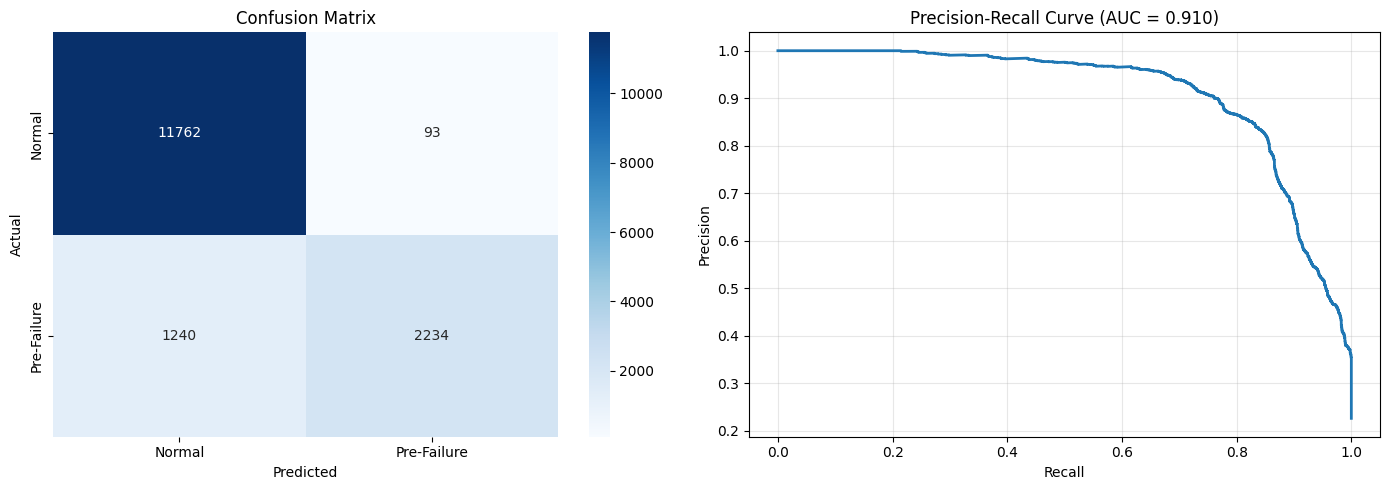

These features in provided data are not utilized by the predictor and will be ignored: ['sensor_46', 'sensor_49']
Computing feature importance via permutation shuffling for 104 features using 5000 rows with 5 shuffle sets...
	779.64s	= Expected runtime (155.93s per shuffle set)
	779.62s	= Actual runtime (Completed 5 of 5 shuffle sets)



Top 20 Feature Importances:
                            importance    stddev       p_value  n  p99_high  \
sensor_0_avg_roll144_mean     0.306925  0.010473  1.624254e-07  5  0.328489   
sensor_43_avg_roll144_mean    0.054106  0.004336  4.907717e-06  5  0.063034   
sensor_13_avg_roll144_mean    0.045474  0.003187  2.876543e-06  5  0.052036   
sensor_13_avg_roll144_std     0.029955  0.002754  8.482948e-06  5  0.035626   
sensor_14_avg_roll144_mean    0.025044  0.003086  2.712063e-05  5  0.031399   
sensor_5_avg_roll144_std      0.018998  0.002681  4.638347e-05  5  0.024519   
sensor_7_avg_roll144_mean     0.018970  0.002611  4.200918e-05  5  0.024346   
sensor_7_avg_roll144_std      0.018371  0.001107  1.576314e-06  5  0.020651   
sensor_41_avg_roll144_mean    0.017337  0.002085  2.461326e-05  5  0.021630   
sensor_53_avg_roll144_std     0.011421  0.000248  2.685479e-08  5  0.011933   
sensor_31_avg_roll144_std     0.009927  0.001080  1.651897e-05  5  0.012150   
sensor_0_avg_roll144_st

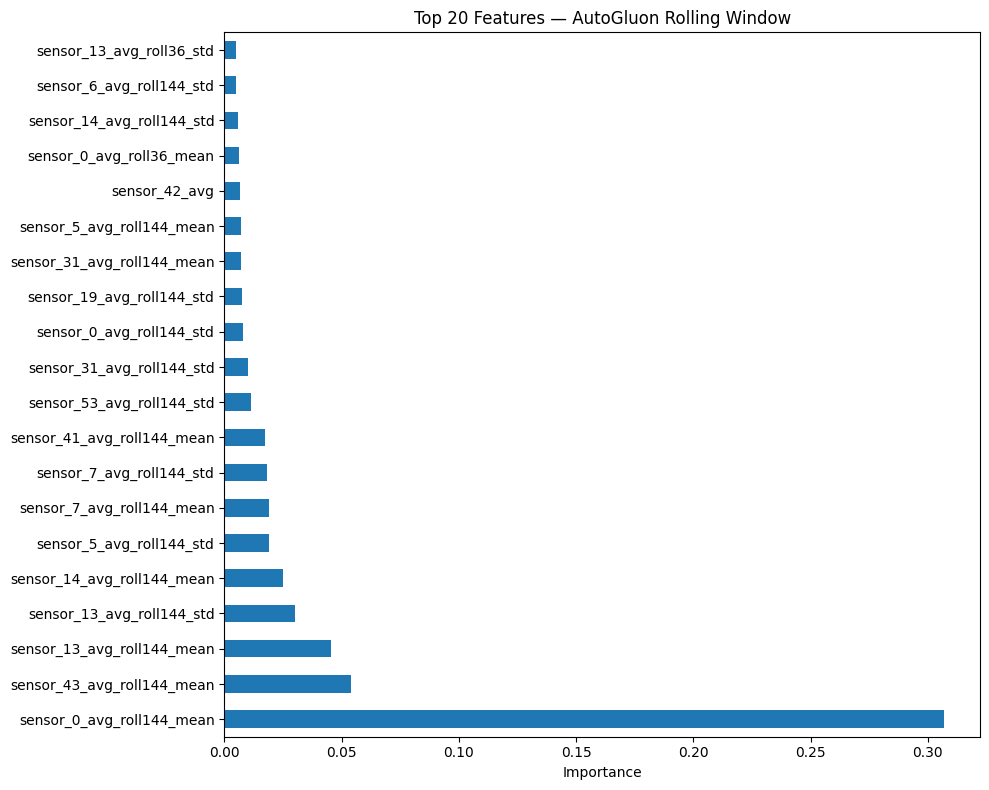


Summary — AutoGluon
Preprocess time:  13.97s
Training time:    642.1s
Total time:       1448.0s
Peak RAM: 4.83 GB
ROC-AUC:          0.9604
PR-AUC:           0.9096
F1:               0.7702
Recall:           0.6431


In [ ]:
!pip install autogluon -q

import pandas as pd
import numpy as np
import warnings
import time
import resource
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, recall_score,
    precision_recall_curve, auc
)
import matplotlib.pyplot as plt
import seaborn as sns
from autogluon.tabular import TabularPredictor
from google.colab import drive

warnings.filterwarnings('ignore')
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/Final_Year_Project/'

def get_peak_ram_gb():
    return resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1e6

total_start = time.time()

FILES = [
    ('WindFarmA', 0),
    ('WindFarmA', 3),
    ('WindFarmA', 10),
    ('WindFarmA', 13),
    ('WindFarmA', 14),
    ('WindFarmA', 17),
]

rolling_cols = [
    'sensor_5_avg',  'sensor_31_avg',
    'sensor_0_avg',  'sensor_43_avg',
    'sensor_53_avg', 'sensor_19_avg',
    'sensor_6_avg',  'sensor_7_avg',
    'sensor_41_avg', 'sensor_13_avg',
    'sensor_14_avg',
]
rolling_windows = [6, 36, 144]

drop_cols = [
    'time_stamp',
    'asset_id',
    'id',
    'train_test',
    'status_type_id',
    'power_29_avg', 'power_29_max', 'power_29_min', 'power_29_std',
    'power_30_avg', 'power_30_max', 'power_30_min', 'power_30_std',
    'wind_speed_3_avg', 'wind_speed_3_max', 'wind_speed_3_min', 'wind_speed_3_std',
    'wind_speed_4_avg',
    'reactive_power_27_avg', 'reactive_power_27_max', 'reactive_power_27_min', 'reactive_power_27_std',
    'reactive_power_28_avg', 'reactive_power_28_max', 'reactive_power_28_min', 'reactive_power_28_std',
    'sensor_35_avg', 'sensor_36_avg', 'sensor_37_avg',
]

# leaky sensors - exclude
dropped_sensors = [
    'sensor_35', 'sensor_36', 'sensor_37',
    'sensor_38', 'sensor_39', 'sensor_40',
    'sensor_18', 'sensor_52',
    'sensor_23', 'sensor_25',
    'sensor_34',
    'sensor_44', 'sensor_48', 'sensor_50',
]

RANDOM_SEED = 42
max_normal = 12_000

preprocess_start = time.time()
all_train, all_test = [], []

for farm, file_num in FILES:
    path = f'{base_path}{farm}/{file_num}.csv'
    df = pd.read_csv(path, sep=';')
    df['time_stamp'] = pd.to_datetime(df['time_stamp'])
    df = df.sort_values('time_stamp').reset_index(drop=True)

    # status 3 = actual fault, exclude from training
    df = df[df['status_type_id'] != 3].copy()
    df['target'] = (df['status_type_id'] == 4).astype(int)

    for col in rolling_cols:
        if col in df.columns:
            for w in rolling_windows:
                df[f'{col}_roll{w}_mean'] = df[col].rolling(w, min_periods=1).mean()
                df[f'{col}_roll{w}_std'] = df[col].rolling(w, min_periods=1).std().fillna(0)

    df = df.dropna().reset_index(drop=True)

    leaky_cols = [c for c in df.columns if any(c.startswith(root + '_') or c == root for root in dropped_sensors)]
    cols_to_drop =  drop_cols + leaky_cols

    train = df[df['train_test'] == 'train'].drop(columns=cols_to_drop, errors='ignore')
    test = df[df['train_test'] == 'prediction'].drop(columns=cols_to_drop, errors='ignore')

    # downsample normal class
    minority = train[train['target'] == 1]
    majority = train[train['target'] == 0]
    n_keep = min(max_normal, len(majority))
    majority_down = majority.sample(n=n_keep, random_state=RANDOM_SEED)
    train = pd.concat([majority_down, minority]).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

    all_train.append(train)
    all_test.append(test)

    print(f"File {farm}/{file_num}: train={len(train):,} | test={len(test):,} | class1={minority.shape[0]:,}")

train_data = pd.concat(all_train, ignore_index=True)
test_data = pd.concat(all_test, ignore_index=True)

print(f"\nCombined → Train: {train_data.shape[0]:,} | Test: {test_data.shape[0]:,}")
print(f"Features: {train_data.shape[1] - 1}")
print(f"\nTrain target:\n{train_data['target'].value_counts()}")
print(f"\nTest target:\n{test_data['target'].value_counts()}")

preprocess_time = time.time() - preprocess_start
print(f"Preprocess time: {preprocess_time:.2f}s")
print(f"Peak RAM: {get_peak_ram_gb():.2f} GB")

start_time = time.time()
predictor = TabularPredictor(
    label='target',
    eval_metric='average_precision',
    path='ag_rolling_benchmark',
    problem_type='binary',
).fit(
    train_data=train_data,
    time_limit=600,
    presets='best_quality',
    verbosity=2,
)

train_time = time.time() - start_time
print(f"Training time: {train_time:.1f}s")
print(f"Peak RAM: {get_peak_ram_gb():.2f} GB")

leaderboard = predictor.leaderboard(test_data, silent=True)
print(leaderboard.to_string())

y_test = test_data['target']
y_prob = predictor.predict_proba(test_data)[1]
y_pred = (y_prob >= 0.50).astype(int)

f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)
rec = recall_score(y_test, y_pred)
prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_prob)
pr = auc(rec_vals, prec_vals)
cm = confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Pre-Failure (1)']))
print(f"ROC-AUC: {roc:.4f}")
print(f"PR-AUC:  {pr:.4f}")
print(f"F1:      {f1:.4f}")
print(f"Recall:  {rec:.4f}")
print(f"\nConfusion Matrix:\n{cm}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pre-Failure'],
            yticklabels=['Normal', 'Pre-Failure'], ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

axes[1].plot(rec_vals, prec_vals, linewidth=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'Precision-Recall Curve (AUC = {pr:.3f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

importance = predictor.feature_importance(test_data)
top20 = importance.head(20)
print("\nTop 20 Feature Importances:")
print(top20)

plt.figure(figsize=(10, 8))
top20['importance'].plot(kind='barh')
plt.xlabel('Importance')
plt.title('Top 20 Features — AutoGluon Rolling Window')
plt.tight_layout()
plt.show()

total_time = time.time() - total_start

print(f"\n{'='*50}")
print(f"Summary — AutoGluon")
print(f"{'='*50}")
print(f"Preprocess time:  {preprocess_time:.2f}s")
print(f"Training time:    {train_time:.1f}s")
print(f"Total time:       {total_time:.1f}s")
print(f"Peak RAM:         {get_peak_ram_gb():.2f} GB")
print(f"ROC-AUC:          {roc:.4f}")
print(f"PR-AUC:           {pr:.4f}")
print(f"F1:               {f1:.4f}")
print(f"Recall:           {rec:.4f}")
print(f"{'='*50}")

np.save('/content/drive/MyDrive/Final_Year_Project/Results/ag_y_prob.npy', y_prob)
np.save('/content/drive/MyDrive/Final_Year_Project/Results/ag_y_true.npy', y_test.values)

In [ ]:
# Train vs Test Check
y_train_pred = predictor.predict(train_data)
train_f1 = f1_score(train_data['target'], y_train_pred)
test_f1 = f1_score(y_test, y_pred)
print(f"Train F1: {train_f1:.4f}")
print(f"Test F1: {test_f1:.4f}")
print(f"Gap: {train_f1 - test_f1:.4f}")

Train F1: 0.9701
Test F1:  0.7702
Gap:      0.1998
